# Simulación de embarque variando la cantidad de pasajeros y costos
Simulamos de 100 a 50 pasajeros con los cuatro métodos de embarque y 1000 muestras por escenario. Vaciamos asientos al azar o sin dejar vacía una pareja completa ventana–pasillo. Los límites elegidos a partir de los que hay demora son 20 y 25 minutos, iguales para todos los métodos. La demora es el tiempo que excede ese límite. Calculamos su probabilidad y el tiempo medio de embarque, con su error de estimación. Evaluamos dos costos separados, ambos cero sin demora. Utilizamos un pasaje de USD 20 como supuesto editable.

In [1]:
import random
import matplotlib.pyplot as plt  # lo subimos acá para no depender de las celdas de las corridas Monte Carlo

# Armamos el avión

n_filas = 25
# -2 es ventana izquierda | -1 es pasillo izquierda | 1 es pasillo derecha | 2 es ventana derecha
lados = [-2, -1, 1, 2]


# Creamos los asientos fila por fila, respetando el orden de los lados.
asientos = []

for fila in range(1, n_filas + 1):
    for lado in lados:
        asiento = (fila, lado)
        asientos.append(asiento)

print(f"Cantidad de asientos: {len(asientos)}") 
print("Primeros 6 asientos:", asientos[:6])

Cantidad de asientos: 100
Primeros 6 asientos: [(1, -2), (1, -1), (1, 1), (1, 2), (2, -2), (2, -1)]


In [ ]:
# Politica Random

def orden_random(asientos):
    cola = asientos.copy()
    random.shuffle(cola)
    return cola


# Politica Back-to-Front

def orden_back_to_front(asientos, n_bloques=5):
    filas_por_bloque = n_filas // n_bloques  

    cola = []

    for bloque in range(n_bloques - 1, -1, -1):
        fila_inicio = bloque * filas_por_bloque + 1     # La fila que cierra el grupo del bloque actual
        fila_final = fila_inicio + filas_por_bloque - 1 # La fila que comienza el grupo del bloque actual

        asientos_bloque = []

        for asiento in asientos:
            fila = asiento[0]   # numero de fila

            if fila_inicio <= fila <= fila_final: # Si estas en una fila del bloque actual
                asientos_bloque.append(asiento)   # Sos parte de los asientos del bloque actual  


        # desordenamos dentro del bloque actual (los otros bloques no se tocan).
        random.shuffle(asientos_bloque) 

        # .extend() agrega todos los elementos de asientos_bloque al final
        cola.extend(asientos_bloque)

    return cola



# Politica Wilma (Window-Middle-Aisle, pero nosotros no tenemos asiento del medio, asi que es Window-Aisle)

def orden_wilma(asientos):
    ventanas = []
    pasillos = []

    for asiento in asientos:
        lado = asiento[1]

        if abs(lado) == 2:
            ventanas.append(asiento)
        else:
            pasillos.append(asiento)

    random.shuffle(ventanas)
    random.shuffle(pasillos)

    return ventanas + pasillos


# Politica Steffen (sin asiento del medio)

def orden_steffen(asientos):

    ventana_derecha_impar = []
    ventana_izquierda_impar = []
    ventana_derecha_par = []
    ventana_izquierda_par = []

    pasillo_derecho_impar = []
    pasillo_izquierdo_impar = []
    pasillo_derecho_par = []
    pasillo_izquierdo_par = []

    for asiento in reversed(asientos):
        fila = asiento[0]
        lado = asiento[1]

        # Ventanas
        if lado == 2:
            if fila % 2 == 1:
                ventana_derecha_impar.append(asiento)
            else:
                ventana_derecha_par.append(asiento)

        elif lado == -2:
            if fila % 2 == 1:
                ventana_izquierda_impar.append(asiento)
            else:
                ventana_izquierda_par.append(asiento)

        # Pasillos
        elif lado == 1:
            if fila % 2 == 1:
                pasillo_derecho_impar.append(asiento)
            else:
                pasillo_derecho_par.append(asiento)

        elif lado == -1:
            if fila % 2 == 1:
                pasillo_izquierdo_impar.append(asiento)
            else:
                pasillo_izquierdo_par.append(asiento)

    return (
        ventana_derecha_impar
        + ventana_izquierda_impar
        + ventana_derecha_par
        + ventana_izquierda_par
        + pasillo_derecho_impar
        + pasillo_izquierdo_impar
        + pasillo_derecho_par
        + pasillo_izquierdo_par
    )

In [3]:
politicas = {
    "Back-to-Front": orden_back_to_front,
    "Random":        orden_random,
    "WILMA":         orden_wilma,
    "Steffen":       orden_steffen,
}

## Embarque paso a paso

`Pasajero` guarda el asiento, el equipaje y su estado. `Avion` mantiene la matriz
de asientos y pasillo. En cada segundo todos deciden con la misma matriz;
después se aplican las acciones en orden de cola y entra el siguiente pasajero.
Los tiempos se sortean cuando comienza cada acción, con `random`.

### Pasajero

In [ ]:
def carry_on (p):
    numero_aleatorio = random.random()

    if numero_aleatorio < p:
        tiene_carry_on = 1
    else:
        tiene_carry_on = 0

    return tiene_carry_on

# Estados posibles de un pasajero
ESTADO_CAMINANDO = 0
ESTADO_SENTADO = 1
ESTADO_BLOQUEADO = 2
ESTADO_GUARDANDO_CARRYON = 3
ESTADO_SENTANDOSE = 4

# Tipos de accion con tiempo (usan fin_accion / tipo_accion_en_curso)
ACCION_CAMINAR = "caminar"
ACCION_GUARDAR_CARRYON = "guardar_carryon"
ACCION_SENTARSE = "sentarse"

COLUMNA_PASILLO = 2  # columna central de self.matriz

class Pasajero:
    """Representa a un pasajero: su asiento, su recorrido y su estado en cada segundo."""

    def __init__(self, asiento, id, p_carryon=0.5):
        self.asiento = asiento              # (fila, lado), fila 1..25, lado en {-2,-1,1,2}
        self.id = id
        self.ubicacion = [-1]               # -1 = todavia no entro al avion
        self.estado = [ESTADO_CAMINANDO]
        self.carryon = carry_on(p_carryon)
        self.carryon_guardado = False
        self.velocidad = 3 * (self.carryon + 1)  # segundos por fila: 3 sin carry-on, 6 con carry-on

        # Accion con tiempo en curso. Caminar, guardar carry-on y sentarse
        # comparten mecanismo: se fija un fin_accion (reloj
        # futuro) y, cuando el reloj lo alcanza, decidir_accion propone
        # la accion "terminar_..." correspondiente.
        self.fin_accion = None
        self.destino_accion = None          # solo lo usan caminar y sentarse
        self.tipo_accion_en_curso = None

    def __repr__(self):
        return (
            f"Pasajero(id={self.id}, asiento={self.asiento}, "
            f"carryon={self.carryon}, estado={self.estado[-1]})"
        )

    def decidir_accion(self, avion):
        """Propone una accion para este segundo, sin modificar al pasajero ni la matriz."""
        ubicacion_actual = self.ubicacion[-1]

        if ubicacion_actual == -1:
            return None  # todavia no entro al avion

        fila_actual, columna_actual = ubicacion_actual

        if columna_actual != COLUMNA_PASILLO:
            return None  # ya esta sentado, fuera del pasillo

        if self.fin_accion is not None:
            if avion.reloj < self.fin_accion:
                return None
            return self._terminar_accion_en_curso(ubicacion_actual)

        if self.estado[-1] not in (ESTADO_CAMINANDO, ESTADO_BLOQUEADO):
            return None

        fila_asiento = self.asiento[0] - 1  # asientos van 1..25, matriz 0..24

        if fila_actual == fila_asiento:
            return self._decidir_en_su_fila(avion, fila_actual)

        return self._decidir_avance_pasillo(avion, fila_actual)

    def _terminar_accion_en_curso(self, ubicacion_actual):
        """Arma la accion 'terminar_...' segun el tipo de accion que estaba en curso."""
        if self.tipo_accion_en_curso == ACCION_CAMINAR:
            return {
                "tipo": "terminar_movimiento",
                "pasajero": self,
                "origen": ubicacion_actual,
                "destino": self.destino_accion,
            }
        if self.tipo_accion_en_curso == ACCION_GUARDAR_CARRYON:
            return {"tipo": "terminar_guardado", "pasajero": self}
        if self.tipo_accion_en_curso == ACCION_SENTARSE:
            return {
                "tipo": "terminar_sentado",
                "pasajero": self,
                "destino": self.destino_accion,
            }
        raise ValueError(f"Tipo de accion en curso desconocido: {self.tipo_accion_en_curso}")

    def _decidir_en_su_fila(self, avion, fila_actual):
        """Decide que hacer cuando el pasajero ya llego a la fila de su asiento."""
        lado = self.asiento[1]
        columna_asiento = COLUMNA_PASILLO + lado

        hay_bloqueador = False
        if abs(lado) == 2:  # asiento ventana, puede haber alguien en el medio
            columna_intermedia = COLUMNA_PASILLO + (1 if lado > 0 else -1)
            hay_bloqueador = avion.matriz[fila_actual, columna_intermedia] != 0

        if self.carryon == 1 and not self.carryon_guardado:
            return {"tipo": "iniciar_guardado", "pasajero": self}

        return {
            "tipo": "iniciar_sentado",
            "pasajero": self,
            "destino": (fila_actual, columna_asiento),
            "hay_bloqueador": hay_bloqueador,
        }

    def _decidir_avance_pasillo(self, avion, fila_actual):
        """Decide si el pasajero puede avanzar una fila mas por el pasillo."""
        fila_siguiente = fila_actual + 1
        destino_vacio = avion.matriz[fila_siguiente, COLUMNA_PASILLO] == 0

        if not destino_vacio:
            return {"tipo": "esperar", "pasajero": self}

        libre_desde = avion.pasillo_libre_desde[fila_siguiente]
        tiempo_libre = avion.reloj - libre_desde
        if tiempo_libre < 3:
            return {"tipo": "esperar", "pasajero": self}

        return {
            "tipo": "iniciar_movimiento",
            "pasajero": self,
            "origen": (fila_actual, COLUMNA_PASILLO),
            "destino": (fila_siguiente, COLUMNA_PASILLO),
        }

    def tiempo_sentado(self):
        """Segundos para sentarse una vez en su fila, sin contar demora por bloqueo."""
        return random.triangular(low=2, high=4, mode=3)

    def tiempo_dejar_pasar(self):
        """Segundos extra si hay que pedirle a alguien sentado que se corra."""
        return random.triangular(low=9, high=13, mode=10)

    def tiempo_guardado_carryon(self):
        """Segundos para guardar el carry-on; 0 si no tiene."""
        if self.carryon == 0:
            return 0
        return random.weibullvariate(alpha=16.0, beta=1.7)

### Avión

In [ ]:
import numpy as np

class Avion:
    def __init__(self, pasajeros):
        self.n_filas = 25
        self.n_columnas = 5
        self.capacidad = self.n_filas * 4
        # La lista ya viene ordenada segun la politica elegida.
        self.pasajeros = list(pasajeros)
        self.matriz = np.zeros((self.n_filas, self.n_columnas), dtype=int)
        self.reloj = 0
        self.historial = []

        # None indica una fila ocupada. -3 permite entrar al comenzar.
        self.pasillo_libre_desde = [-3] * self.n_filas

    def cantidad_pasajeros(self):
        """Cuenta los pasajeros a bordo, tanto en el pasillo como en asientos."""
        return np.count_nonzero(self.matriz)

    def cantidad_sentados(self):
        """Cuenta solamente a quienes ya terminaron de sentarse."""
        cantidad = 0
        for pasajero in self.pasajeros:
            if pasajero.estado[-1] == ESTADO_SENTADO:
                cantidad += 1
        return cantidad

    def esta_lleno(self):
        """El embarque termina cuando todos los pasajeros presentes están sentados."""
        return self.cantidad_sentados() == len(self.pasajeros)

    def colocar_en_pasillo(self, pasajero, fila=1):
        """Prepara una prueba antes de avanzar el reloj. Las filas van de 1 a 25."""
        posicion = (fila - 1, COLUMNA_PASILLO)
        self.matriz[posicion] = pasajero.id
        self.pasillo_libre_desde[fila - 1] = None
        pasajero.ubicacion[-1] = posicion
        pasajero.estado[-1] = ESTADO_CAMINANDO

    def ingresar_siguiente_pasajero(self):
        """Entra uno por la puerta si estuvo libre al menos tres segundos."""
        puerta = (0, COLUMNA_PASILLO)
        if self.matriz[puerta] != 0:
            return None
        if self.reloj - self.pasillo_libre_desde[0] < 3:
            return None

        for pasajero in self.pasajeros:
            if pasajero.ubicacion[-1] == -1:
                self.matriz[puerta] = pasajero.id
                self.pasillo_libre_desde[0] = None
                pasajero.ubicacion[-1] = puerta
                pasajero.estado[-1] = ESTADO_CAMINANDO
                # Si se llama entre pasos, actualizamos la foto de este segundo.
                if self.historial and self.historial[-1]["segundo"] == self.reloj:
                    self.historial[-1]["matriz"] = self.matriz.copy()
                return pasajero
        return None

    def avanzar_un_segundo(self):
        """Todos deciden con la misma matriz; despues se aplican las acciones."""
        if not self.historial:
            self.historial.append({"segundo": self.reloj, "matriz": self.matriz.copy()})

        self.reloj += 1
        acciones_pendientes = []
        for pasajero in self.pasajeros:
            accion = pasajero.decidir_accion(self)
            if accion is not None:
                acciones_pendientes.append(accion)

        # La nueva entrada representa este segundo. Si hay una accion,
        # aplicar_accion modifica esa entrada sin tocar el segundo anterior.
        for pasajero in self.pasajeros:
            pasajero.ubicacion.append(pasajero.ubicacion[-1])
            pasajero.estado.append(pasajero.estado[-1])

        for accion in acciones_pendientes:
            self.aplicar_accion(accion)

        # Quien entra ahora empieza a decidir en el proximo segundo.
        self.ingresar_siguiente_pasajero()
        self.historial.append({"segundo": self.reloj, "matriz": self.matriz.copy()})

    def _mover_pasajero(self, pasajero, destino):
        """Actualiza la matriz y registra cuando se libero el origen."""
        origen = pasajero.ubicacion[-1]
        self.matriz[origen] = 0
        self.pasillo_libre_desde[origen[0]] = self.reloj
        self.matriz[destino] = pasajero.id
        if destino[1] == COLUMNA_PASILLO:
            self.pasillo_libre_desde[destino[0]] = None
        pasajero.ubicacion[-1] = destino

    def _limpiar_accion(self, pasajero):
        """Al terminar, dejamos al pasajero listo para decidir otra accion."""
        pasajero.fin_accion = None
        pasajero.destino_accion = None
        pasajero.tipo_accion_en_curso = None

    def aplicar_accion(self, accion):
        """Aplica las acciones propuestas por Pasajero.decidir_accion."""
        pasajero = accion["pasajero"]
        tipo = accion["tipo"]

        if tipo == "esperar":
            pasajero.estado[-1] = ESTADO_BLOQUEADO

        elif tipo == "iniciar_movimiento":
            pasajero.destino_accion = accion["destino"]
            pasajero.fin_accion = self.reloj + pasajero.velocidad
            pasajero.tipo_accion_en_curso = ACCION_CAMINAR
            pasajero.estado[-1] = ESTADO_CAMINANDO
            # Permanece en el origen hasta terminar. Como solo se avanza
            # una fila y nadie comparte origen, no hacen falta reservas.

        elif tipo == "terminar_movimiento":
            self._mover_pasajero(pasajero, accion["destino"])
            self._limpiar_accion(pasajero)
            pasajero.estado[-1] = ESTADO_CAMINANDO

        elif tipo == "iniciar_guardado":
            pasajero.fin_accion = self.reloj + pasajero.tiempo_guardado_carryon()
            pasajero.tipo_accion_en_curso = ACCION_GUARDAR_CARRYON
            pasajero.estado[-1] = ESTADO_GUARDANDO_CARRYON

        elif tipo == "terminar_guardado":
            pasajero.carryon_guardado = True
            self._limpiar_accion(pasajero)
            pasajero.estado[-1] = ESTADO_CAMINANDO

        elif tipo == "iniciar_sentado":
            duracion = pasajero.tiempo_sentado()
            if accion["hay_bloqueador"]:
                duracion += pasajero.tiempo_dejar_pasar()
            pasajero.destino_accion = accion["destino"]
            pasajero.fin_accion = self.reloj + duracion
            pasajero.tipo_accion_en_curso = ACCION_SENTARSE
            pasajero.estado[-1] = ESTADO_SENTANDOSE

        elif tipo == "terminar_sentado":
            self._mover_pasajero(pasajero, accion["destino"])
            self._limpiar_accion(pasajero)
            pasajero.estado[-1] = ESTADO_SENTADO

### Simular un embarque

In [ ]:
def crear_pasajeros(cola, p_carryon):
    pasajeros = []
    for id, asiento in enumerate(cola, start=1):
        pasajeros.append(Pasajero(asiento, id, p_carryon))
    return pasajeros

def simular_embarque(cola, p_carryon=0.5):
    pasajeros = crear_pasajeros(cola, p_carryon)
    avion = Avion(pasajeros)
    avion.ingresar_siguiente_pasajero()
    while not avion.esta_lleno():
        avion.avanzar_un_segundo()
    return avion.reloj

## Parámetros

Usamos 1000 muestras por escenario y dos umbrales fijos. Ya no necesitamos
calibración: son 404 000 embarques, con el avión lleno compartido entre las
dos reglas. Ambos umbrales y ambos costos usan las mismas muestras.

In [5]:
import pandas as pd

M = 1000
p_carryon = 0.5
semilla = 42
umbrales = [20, 25]
ocupaciones = range(100, 49, -1)
reglas = ['Aleatorios', 'Sin contigüidad']

## Asientos vacíos y Monte Carlo

Hay dos reglas de vacíado del avión. En la primera se eligen aleatoriamente los asientos que no seran ocupados, mientras que en la segunda los asientos que no serán ocupados no pueden estar contiguos a otro asiento ya desocupado (es decir no habrá en una fila de un lado dos asientos juntoss desocupados). Evidentemente, la evaluación con 100 pasajeros se comparte entre ambas reglas de vaciado (porque no existe tal vaciado).

In [ ]:
# Esta función genera "colas" de desocupación de asientos.
def orden_para_vaciar(regla):
    if regla == 'Aleatorios':
        return random.sample(asientos, 50)

    elegidos = []
    for fila in range(1, 26): # se elige un asiento por fila y lado para desocupar
        elegidos.append(random.choice([(fila, -2), (fila, -1)]))
        elegidos.append(random.choice([(fila, 1), (fila, 2)]))
    random.shuffle(elegidos)
    return elegidos

In [ ]:
def simular_evaluacion():
    columnas = ['replica', 'metodo', 'regla', 'pasajeros', 'segundos']
    filas = []
    for replica in range(M): # En cada replica se simula un embarque de cada tipo (combinación de regla de vaciado, politica de llenado, y cantidad de pasajeros). De esta forma, al terminar de ejecutarse hay 1000 muestras de cada tipo.
        random.seed(semilla + 2 * replica + 1) # pongo una semilla por replica para replicabilidad de las simulaciones
        vaciar = {}
        for regla in reglas:
            vaciar[regla] = orden_para_vaciar(regla)

        for metodo, politica in politicas.items(): # agarro el nombre del método y la función correspondiente
            cola_completa = politica(asientos)
            lleno = simular_embarque(cola_completa, p_carryon)
            for regla in reglas:
                cola = cola_completa.copy()
                filas.append([replica, metodo, regla, 100, lleno])
                for asiento in vaciar[regla]:
                    cola.remove(asiento)
                    tiempo = simular_embarque(cola, p_carryon)
                    filas.append([replica, metodo, regla, len(cola), tiempo])

        if (replica + 1) % 10 == 0 or replica == M - 1:
            print('evaluacion', replica + 1, '/', M)
    return pd.DataFrame(filas, columns=columnas)

In [ ]:
muestras = simular_evaluacion() # se corren 404.000 simulaciones en total, 101.000 por método de embarque, 51.000 por metódo de vaciado y embarque.

## Umbrales elegidos

Los límites de 20 y 25 minutos son decisiones basadas en los mejores tiempos de embarque de eerolineas en el mundo en 2026 (https://simpleflying.com/airlines-fastest-boarding-times-world/) y el TAT promedio programado de Ryanair en 2013 (https://www.sec.gov/Archives/edgar/data/1038683/000119312513312061/d559127d20f.htm). A partir de estos límites se considera que hay demora. Es decir, hay demora si T > límite, y la demora es de max(T − límite, 0).

In [ ]:
tabla_umbrales = pd.DataFrame({'umbral_min': umbrales})
display(tabla_umbrales)

,umbral_min
0,20
1,25


## Costos en dólares de 2026

Analizamos dos funciones por separado tomando los valores de referencia de EUROCONTROL (https://www.eurocontrol.int/sites/default/files/2024-05/eurocontrol-standard-inputs-economic-analyses-ed-10.pdf) ajustandolos utilizando la proyección de inflación HICP de la eurozona del BCE y pasandolos a dólares con el cambio de referencia de la BCE. Ambas dependen de los minutos de demora y valen cero cuando no hay demora.

**Tácticos:** interpolación lineal entre (0, 0), (5, 92,8503),
(15, 494,0553) y (30, 1777,9113).

**Estratégicos:** 13,899556175 USD por minuto de demora.

In [ ]:
def costo_tactico(demora):
    demora = np.maximum(demora, 0)
    if np.any(demora > 30):
        raise ValueError('Hay demoras mayores a 30 minutos: ampliar la tabla de costos tácticos.')
    # Rectas entre los costos totales a 0, 5, 15 y 30 minutos.
    return np.interp(demora, [0, 5, 15, 30], [0, 92.8503, 494.0553, 1777.9113])

def costo_estrategico(demora):
    return 13.899556175 * np.maximum(demora, 0)

funciones_costo = {'Tácticos': costo_tactico, 'Estratégicos': costo_estrategico}

def error_estimacion(valores):
    return 1.96 * np.std(valores) / np.sqrt(len(valores))

## Estadísticas y comparación con el avión lleno

La probabilidad de demora es el promedio de $h_j=1\{T_j>tiempolimite\}$. Su error es $1.96\sqrt{\overline{h^2}-\overline h^2}/\sqrt M$ y el relativo aproximado es $1.96/(\sqrt{\hat P}\sqrt M)$, válido para probabilidades pequeñas.

Para cada ocupación n, comparamos con 100 pasajeros del mismo método y regla de vacíado:

**Mejora = costo con 100 − costo con n − (100 − n) × precio del pasaje.** (que es la diferencia entre los ingresos netos de cada cantidad de pasajeros)

Calculamos esta diferencia en cada réplica y luego su media y su error como $1.96\,\mathrm{desvío}(\mathrm{mejoras})/\sqrt M$.

In [ ]:
precio_pasaje = 20  # USD por asiento supuesto (se puede variar).

In [ ]:
# Emparejamos ocupaciones por número de réplica.
tiempos = {}
for clave, grupo in muestras.groupby(['metodo', 'regla', 'pasajeros']):
    grupo = grupo.sort_values('replica')
    tiempos[clave] = grupo['segundos'].to_numpy() / 60

filas_estadisticas = []
costos_muestras = {}
for (metodo, regla, n), t in tiempos.items():
    for limite in umbrales:
        demora = np.maximum(t - limite, 0)
        h = (t > limite).astype(int)
        probabilidad = np.mean(h)
        sigma_h = np.sqrt(np.mean(h**2) - np.mean(h)**2)
        error_rel = np.nan
        if probabilidad > 0:
            error_rel = 1.96 / (np.sqrt(probabilidad) * np.sqrt(M))
        filas_estadisticas.append({
            'metodo': metodo, 'regla': regla, 'pasajeros': n,
            'umbral_min': limite, 'muestras': M, 'demoras': np.sum(h),
            'prob_demora': probabilidad, 'error_prob': 1.96 * sigma_h / np.sqrt(M),
            'error_rel_aprox': error_rel, 'tiempo_medio_min': np.mean(t),
            'desvio_min': np.std(t), 'error_media_min': error_estimacion(t)
        })
        for analisis, funcion in funciones_costo.items():
            costos_muestras[analisis, metodo, regla, n, limite] = funcion(demora)

filas_costos = []
for (analisis, metodo, regla, n, limite), costos in costos_muestras.items():
    lleno = costos_muestras[analisis, metodo, regla, 100, limite]
    ingreso_bruto = n * precio_pasaje
    mejora = lleno - costos - (100 - n) * precio_pasaje
    filas_costos.append({
        'analisis': analisis, 'metodo': metodo, 'regla': regla,
        'pasajeros': n, 'asientos_vacios': 100 - n, 'umbral_min': limite,
        'ingreso_bruto_usd': ingreso_bruto,
        'costo_total_medio_usd': np.mean(costos),
        'error_costo_usd': error_estimacion(costos),
        'ingreso_neto_usd': ingreso_bruto - np.mean(costos),
        'mejora_vs_lleno_usd': np.mean(mejora),
        'error_mejora_usd': error_estimacion(mejora)
    })
tabla = pd.DataFrame(filas_estadisticas)
tabla_costos = pd.DataFrame(filas_costos)
display(tabla.head(8))
print('Estadísticas:', len(tabla), 'filas. Análisis económicos:', len(tabla_costos), 'filas.')

,metodo,regla,pasajeros,umbral_min,muestras,demoras,prob_demora,error_prob,error_rel_aprox,tiempo_medio_min,desvio_min,error_media_min
0,Back-to-Front,Aleatorios,50,20,1000,0,0.0,0.0,NaN,13.953283,0.823128,0.051018
1,Back-to-Front,Aleatorios,50,25,1000,0,0.0,0.0,NaN,13.953283,0.823128,0.051018
2,Back-to-Front,Aleatorios,51,20,1000,0,0.0,0.0,NaN,14.251767,0.836517,0.051848
3,Back-to-Front,Aleatorios,51,25,1000,0,0.0,0.0,NaN,14.251767,0.836517,0.051848
4,Back-to-Front,Aleatorios,52,20,1000,0,0.0,0.0,NaN,14.559283,0.824684,0.051114
5,Back-to-Front,Aleatorios,52,25,1000,0,0.0,0.0,NaN,14.559283,0.824684,0.051114
6,Back-to-Front,Aleatorios,53,20,1000,0,0.0,0.0,NaN,14.866733,0.854791,0.052980
7,Back-to-Front,Aleatorios,53,25,1000,0,0.0,0.0,NaN,14.866733,0.854791,0.052980


Estadísticas: 816 filas. Análisis económicos: 1632 filas.


## Ingreso bruto, costo total medio e ingreso neto

Para cada método, umbral, tipo de costos, y regla de vaciado, graficamos ingreso bruto = pasajeros × precio; ingreso neto medio = ingreso bruto − costo total medio de demora; costo total medio. Notese que esto evidentemente no es la ganancia total del vuelo, ya que no se incluyen más que los costos de demora. Las bandas muestran ± error de estimación del costo medio y los ingresos netos medios tienen el mismo error porque el ingreso bruto es fijo.

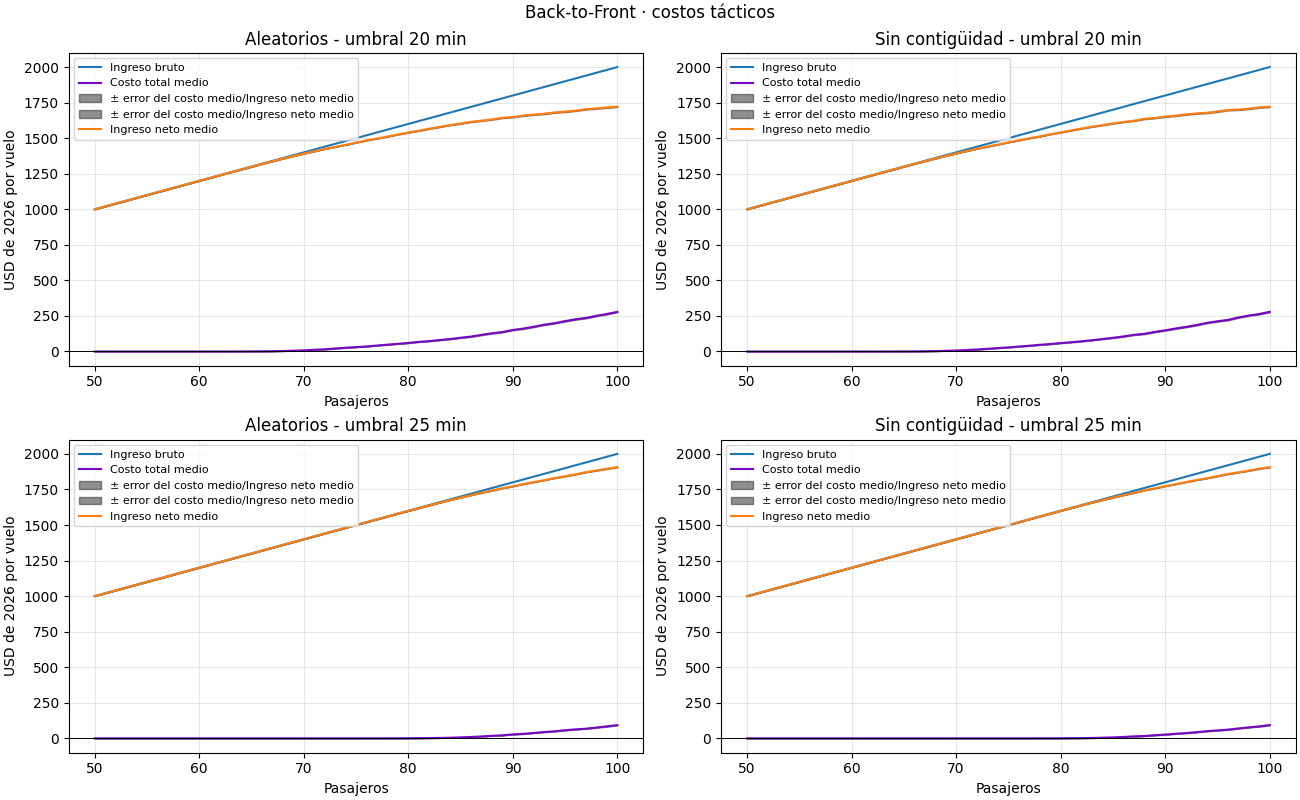

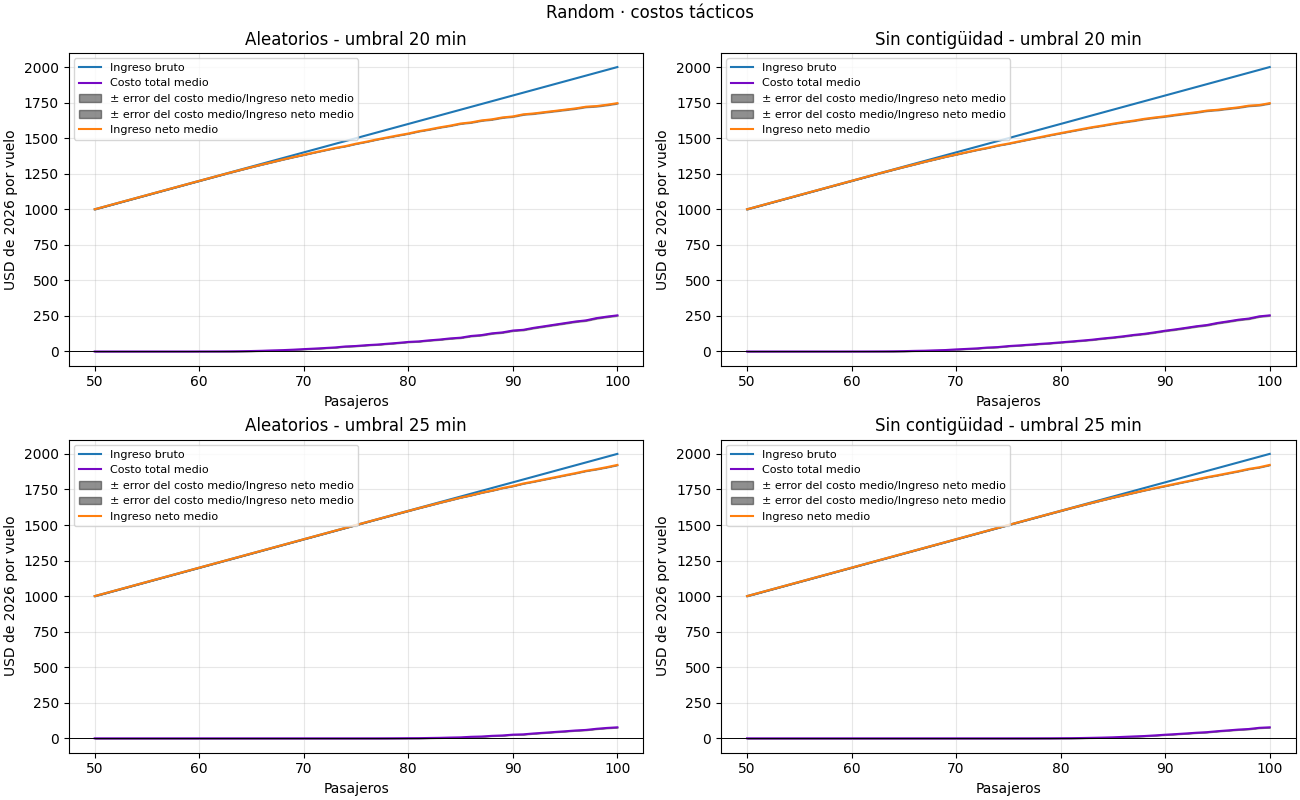

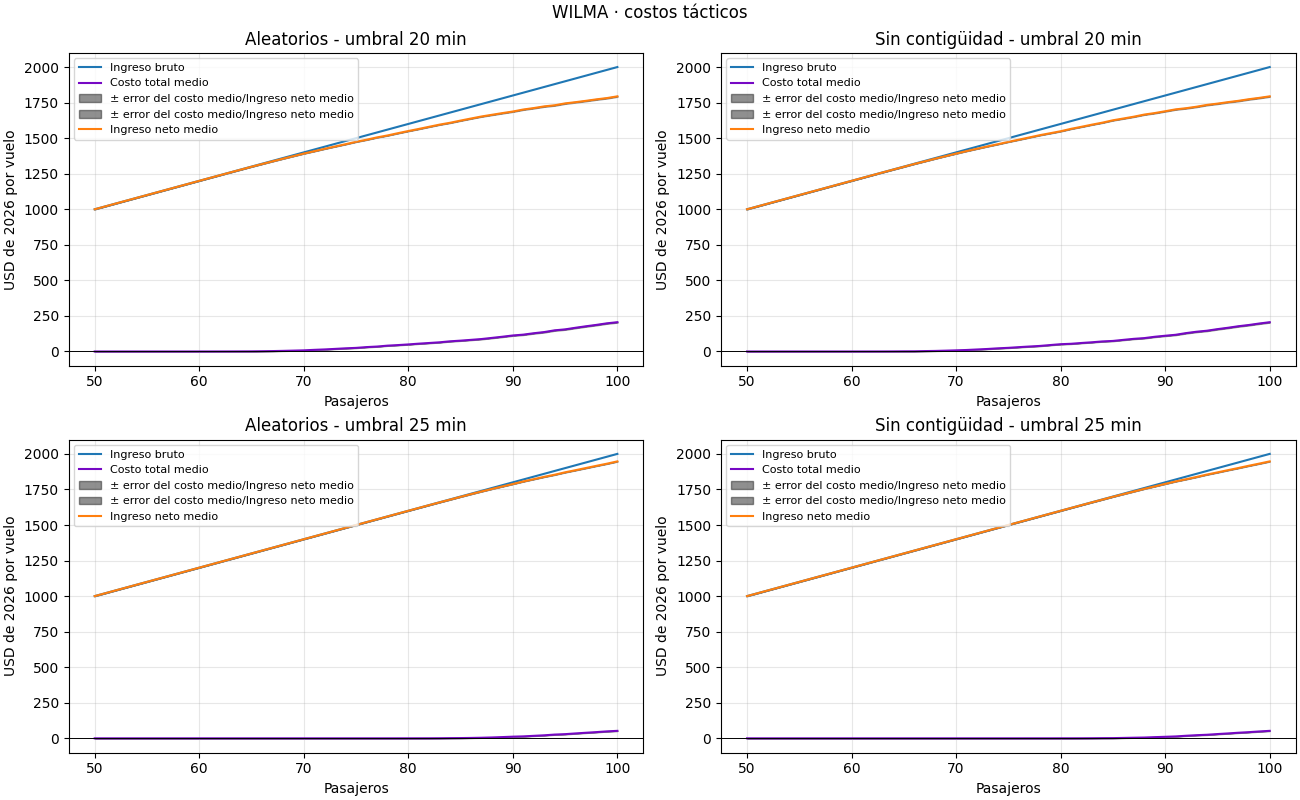

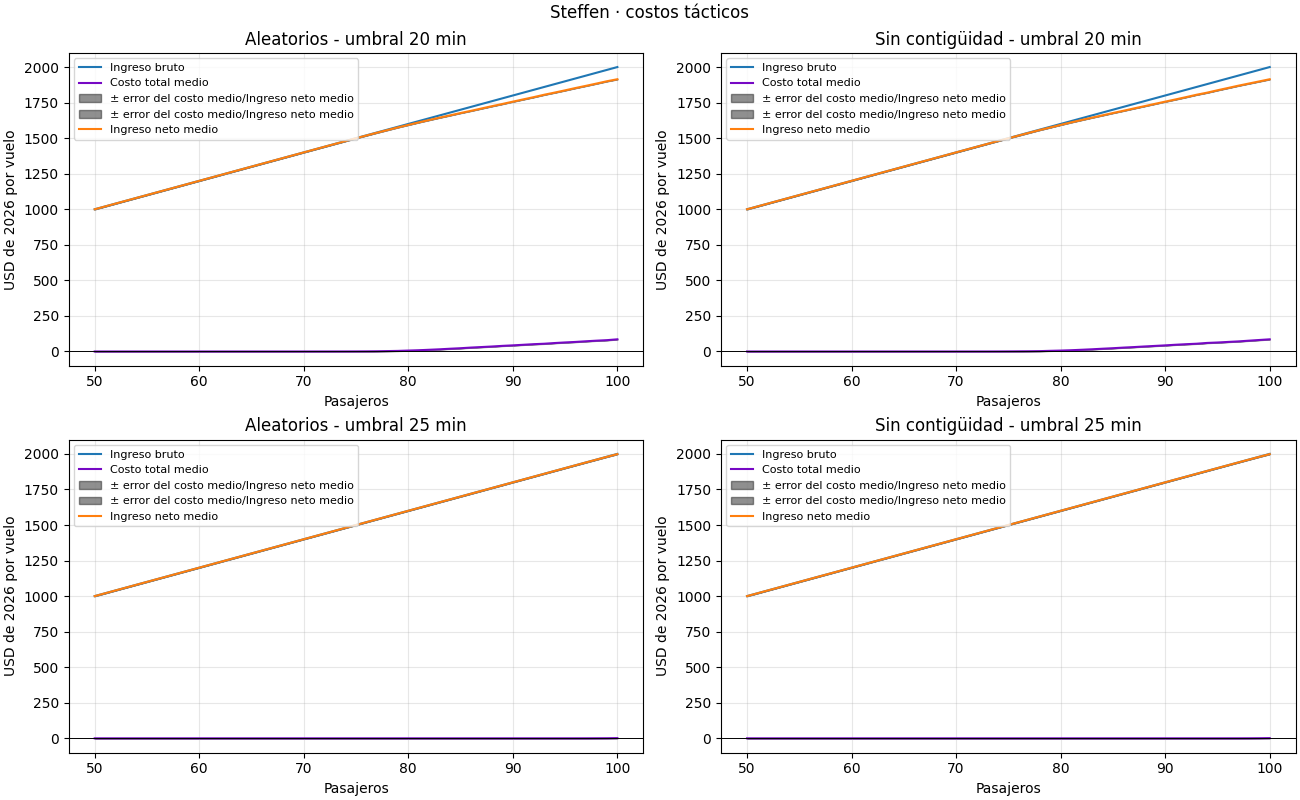

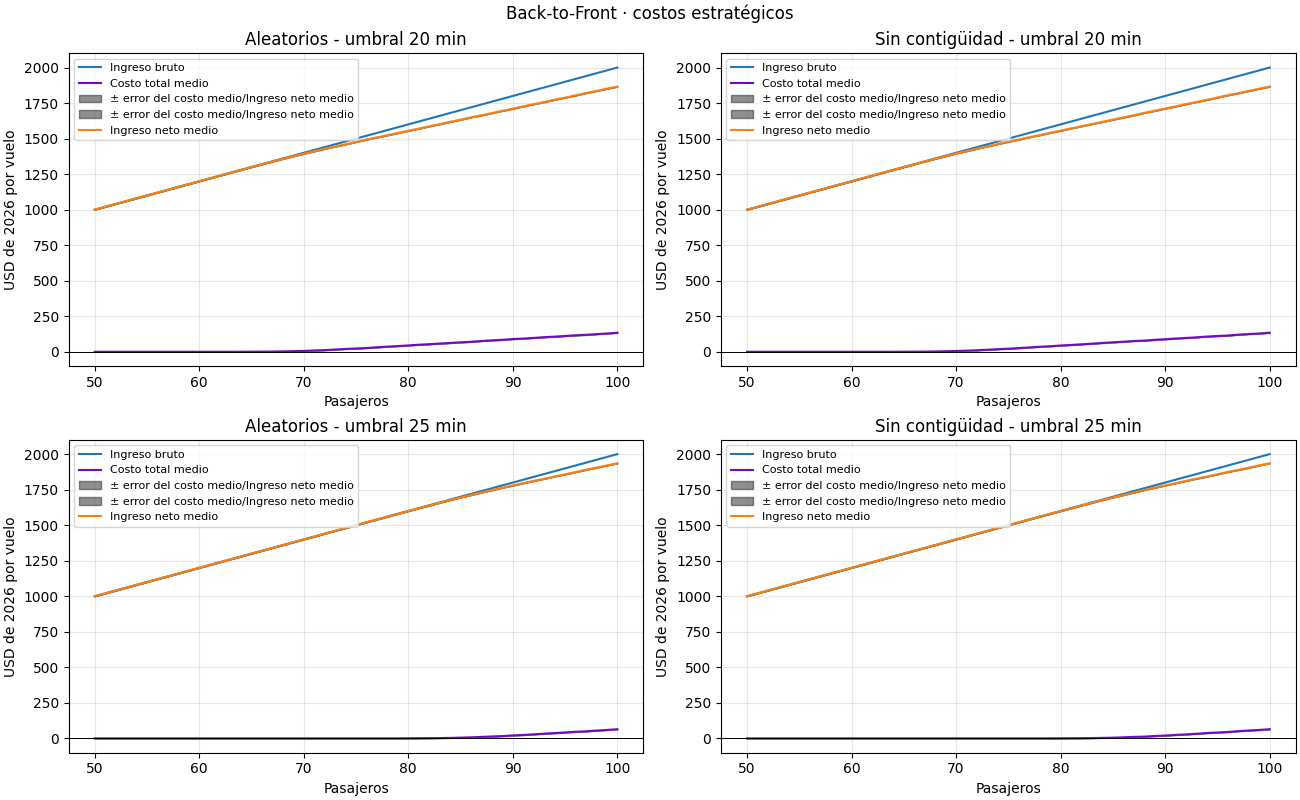

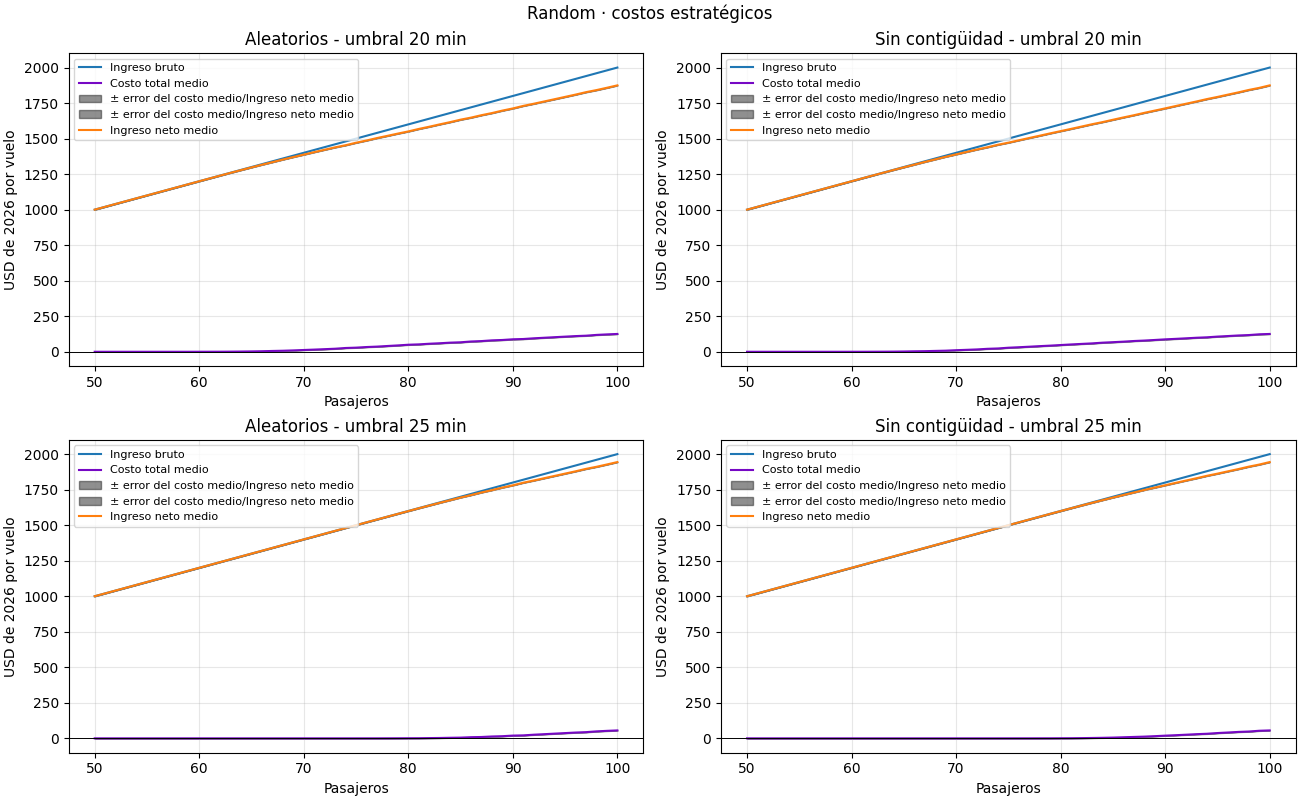

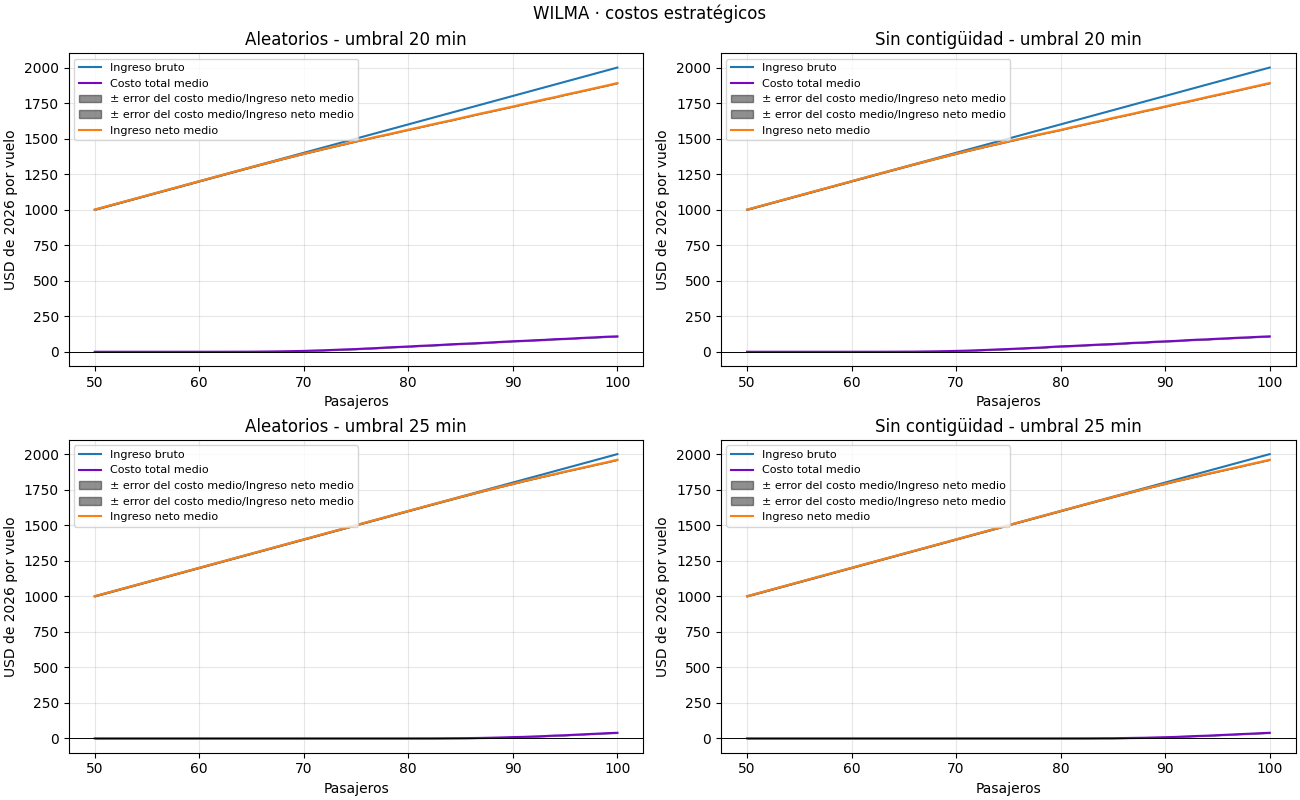

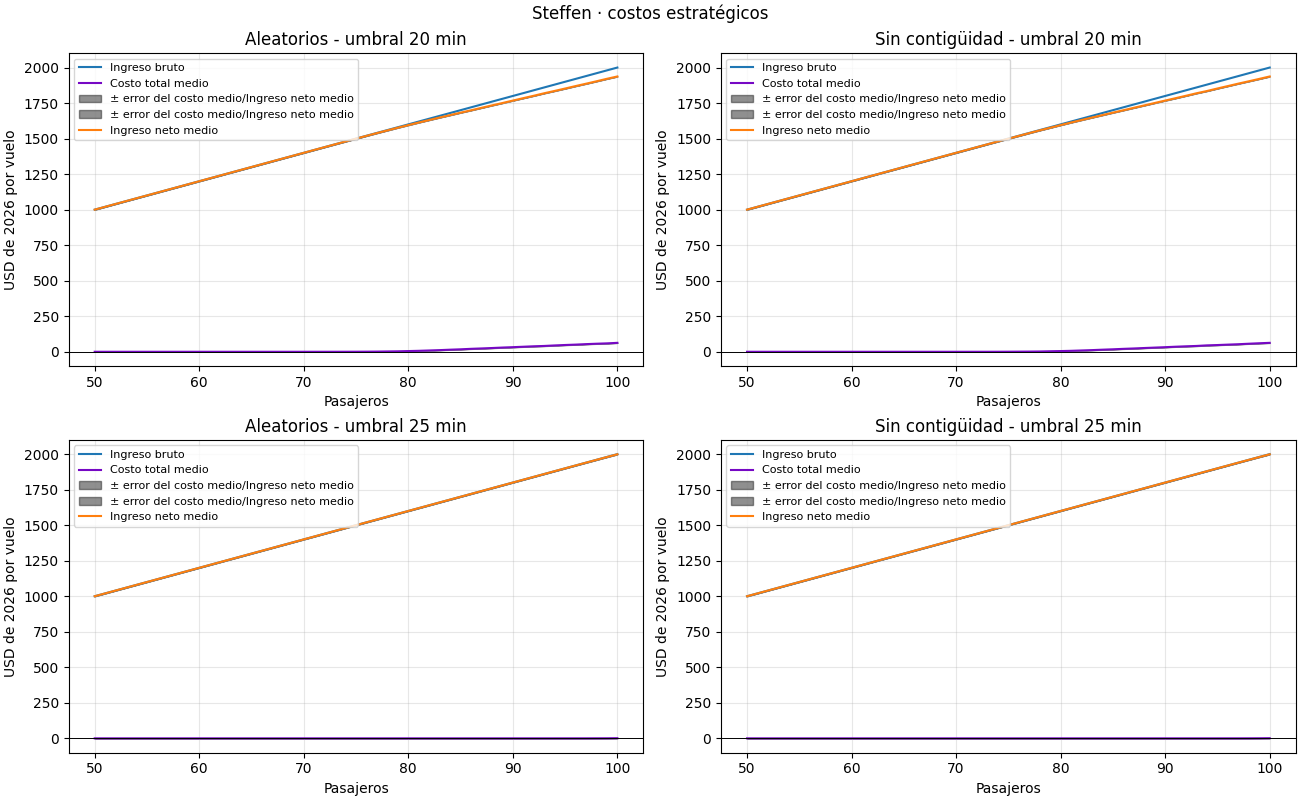

In [ ]:
for analisis in funciones_costo:
    for metodo in politicas:
        fig, ejes = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)
        for fila, limite in enumerate(umbrales):
            for columna, regla in enumerate(reglas):
                eje = ejes[fila, columna]
                datos = tabla_costos[(tabla_costos['analisis'] == analisis) &
                                     (tabla_costos['metodo'] == metodo) &
                                     (tabla_costos['umbral_min'] == limite) &
                                     (tabla_costos['regla'] == regla)].sort_values('pasajeros')
                n = datos['pasajeros']
                costo = datos['costo_total_medio_usd']
                error = datos['error_costo_usd']
                eje.plot(n, datos['ingreso_bruto_usd'], color='tab:blue', label='Ingreso bruto')
                eje.plot(n, costo, color="#7608c4", label='Costo total medio')
                eje.fill_between(n, costo - error, costo + error, color="#202020", alpha=0.5,
                                 label='± error del costo medio/Ingreso neto medio')
                eje.fill_between(n, datos['ingreso_neto_usd'] - error, datos['ingreso_neto_usd'] + error, color='#202020', alpha=0.5,
                                 label='± error del costo medio/Ingreso neto medio')
                eje.plot(n, datos['ingreso_neto_usd'], color='tab:orange', label='Ingreso neto medio')
                eje.axhline(0, color='black', linewidth=0.7)
                eje.set_title(f'{regla} - umbral {limite} min')
                eje.set_xlabel('Pasajeros')
                eje.set_ylabel('USD de 2026 por vuelo')
                eje.grid(alpha=0.3)
                eje.legend(loc="upper left",fontsize=8)
        fig.suptitle(f'{metodo} · costos {analisis.lower()}')
        plt.show()

### Probabilidad de demora y tiempo medio (con error de estimación)

Las bandas muestran la estimación ± su error: $1.96\,\sigma_h/\sqrt M$ para la probabilidad y $1.96\,s_T/\sqrt M$ para el tiempo medio.
Cero demoras observadas producen un error estimado cero con esta fórmula.

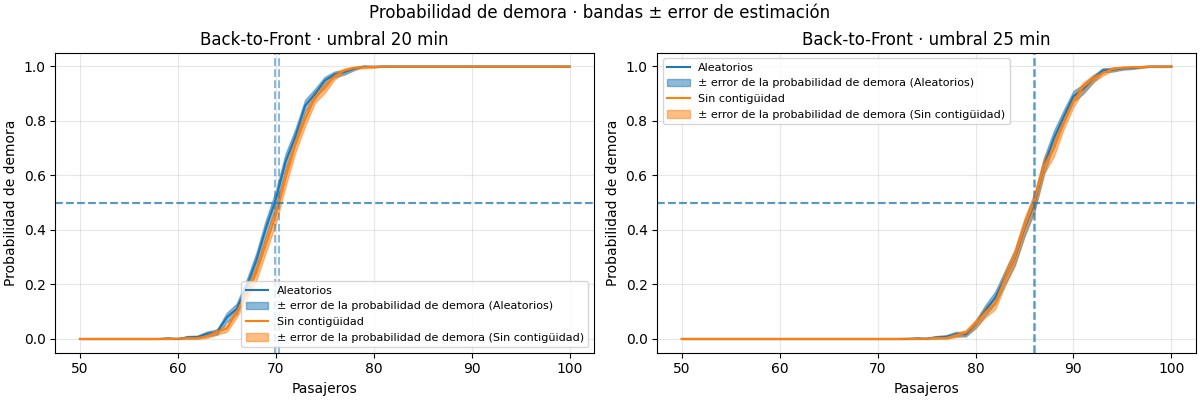

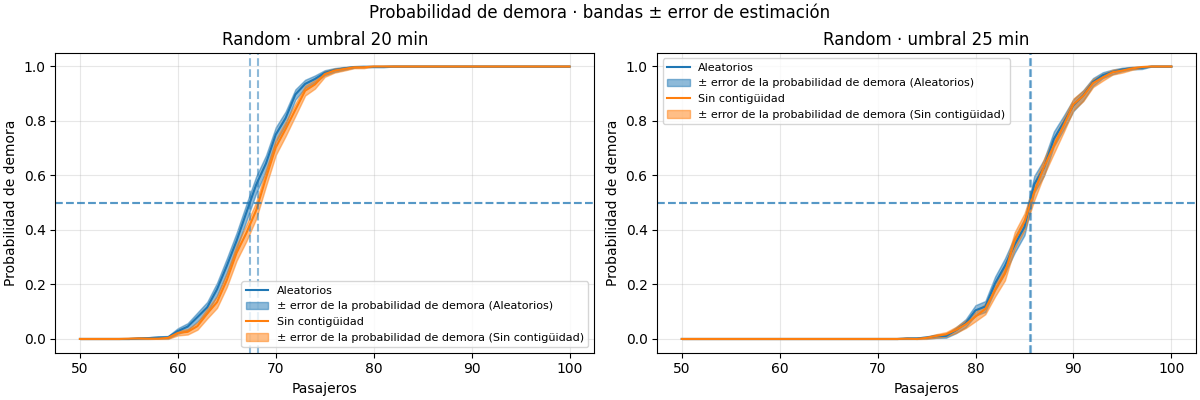

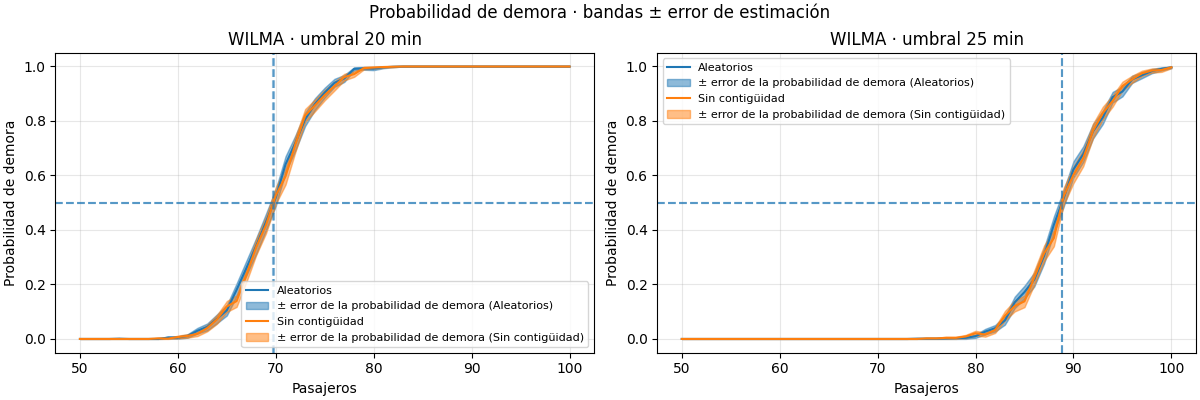

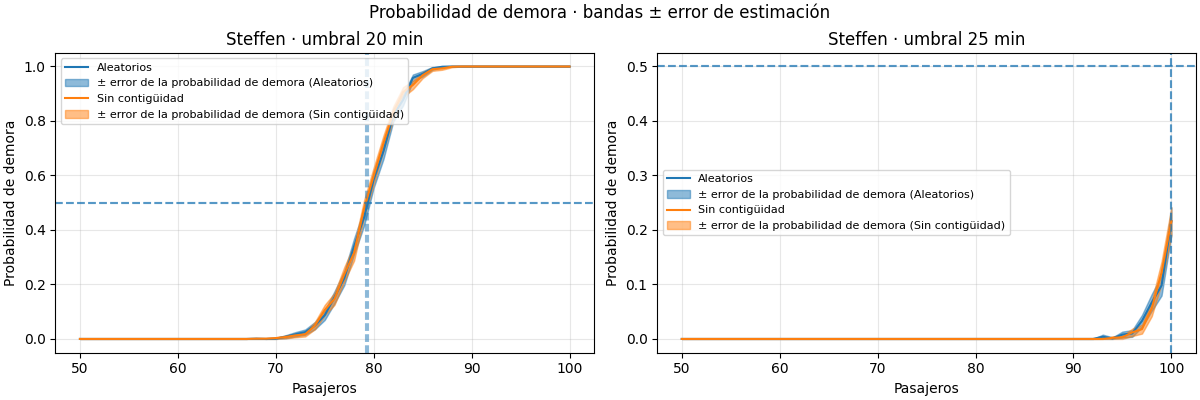

En la regla Aleatorios para la politica Back-to-Front con el umbral 20 P(demora)=0.5 es con aprox. 69.89 pasajeros
En la regla Sin contigüidad para la politica Back-to-Front con el umbral 20 P(demora)=0.5 es con aprox. 70.34 pasajeros
En la regla Aleatorios para la politica Back-to-Front con el umbral 25 P(demora)=0.5 es con aprox. 86.03 pasajeros
En la regla Sin contigüidad para la politica Back-to-Front con el umbral 25 P(demora)=0.5 es con aprox. 85.96 pasajeros
En la regla Aleatorios para la politica Random con el umbral 20 P(demora)=0.5 es con aprox. 67.35 pasajeros
En la regla Sin contigüidad para la politica Random con el umbral 20 P(demora)=0.5 es con aprox. 68.24 pasajeros
En la regla Aleatorios para la politica Random con el umbral 25 P(demora)=0.5 es con aprox. 85.57 pasajeros
En la regla Sin contigüidad para la politica Random con el umbral 25 P(demora)=0.5 es con aprox. 85.64 pasajeros
En la regla Aleatorios para la politica WILMA con el umbral 20 P(demora)=0.5 es con apro

In [ ]:
for metodo in politicas:
    fig, ejes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
    for eje, limite in zip(ejes.flat, umbrales):
        for regla in reglas:
            datos = tabla[(tabla['metodo'] == metodo) & (tabla['regla'] == regla) &
                          (tabla['umbral_min'] == limite)].sort_values('pasajeros')
            media = datos['prob_demora']
            error = datos['error_prob']
            linea, = eje.plot(datos['pasajeros'], media, label=regla)
            eje.fill_between(datos['pasajeros'], np.maximum(0, media - error),
                             np.minimum(1, media + error),
                             color=linea.get_color(), alpha=0.5, label=f'± error de la probabilidad de demora ({regla})')
            pasajeros_50 = np.interp(
                0.5,
                datos['prob_demora'],
                datos['pasajeros']
            )
            print(f"En la regla {regla} para la politica {metodo} con el umbral {limite} P(demora)=0.5 es con aprox. {pasajeros_50:.2f} pasajeros")
            eje.axhline(0.5, linestyle='--', alpha=0.5)
            eje.axvline(pasajeros_50, linestyle='--', alpha=0.5)
        eje.set_title(f'{metodo} · umbral {limite} min')
        eje.set_xlabel('Pasajeros')
        eje.set_ylabel('Probabilidad de demora')
        eje.grid(alpha=0.3)
        eje.legend(fontsize=8)
    fig.suptitle('Probabilidad de demora · bandas ± error de estimación')
plt.show()

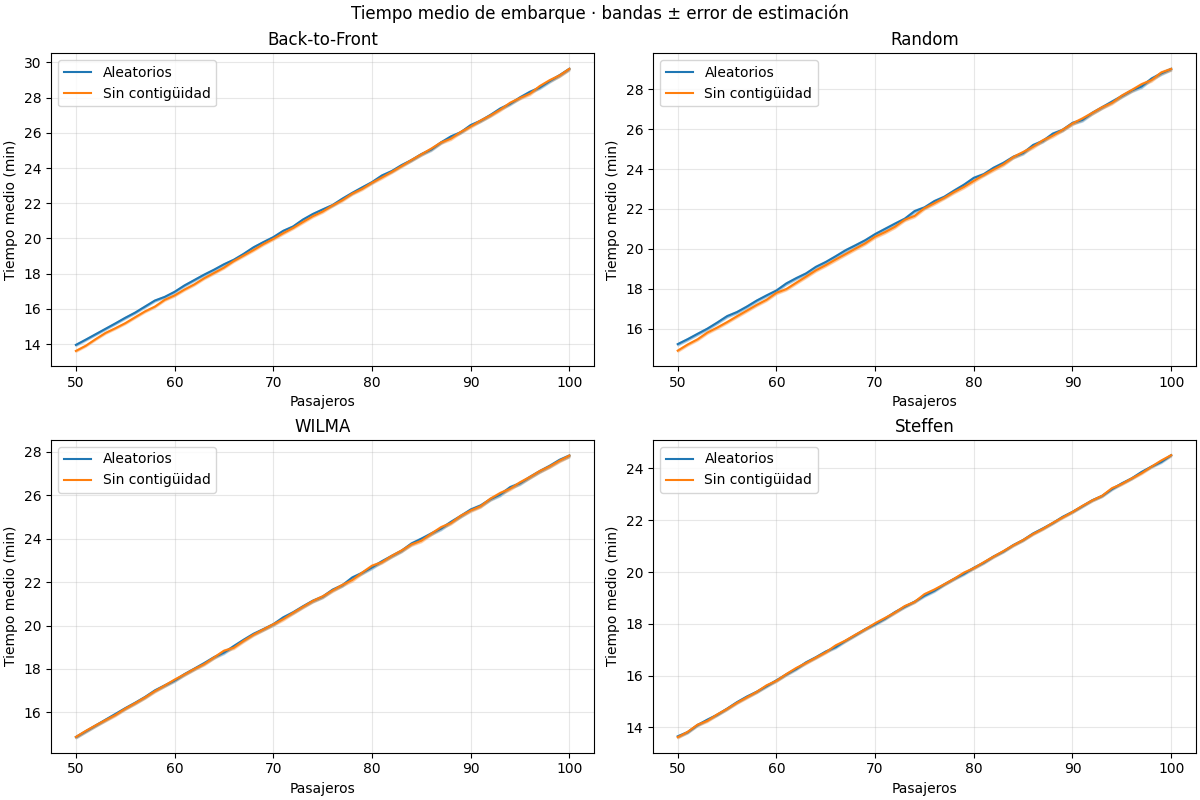

In [ ]:
# Como la media no depende del límite graficamos una sola curva por método y regla
fig, ejes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
for eje, metodo in zip(ejes.flat, politicas):
    for regla in reglas:
        datos = tabla[(tabla['metodo'] == metodo) & (tabla['regla'] == regla)]
        datos = datos.drop_duplicates('pasajeros').sort_values('pasajeros')
        linea, = eje.plot(datos['pasajeros'], datos['tiempo_medio_min'], label=regla)
        eje.fill_between(datos['pasajeros'],
                         datos['tiempo_medio_min'] - datos['error_media_min'],
                         datos['tiempo_medio_min'] + datos['error_media_min'],
                         color=linea.get_color(), alpha=0.3)
    eje.set_title(metodo)
    eje.set_xlabel('Pasajeros')
    eje.set_ylabel('Tiempo medio (min)')
    eje.grid(alpha=0.3)
    eje.legend()
fig.suptitle('Tiempo medio de embarque · bandas ± error de estimación')
plt.show()

## Mejores casos

Para cada análisis buscamos la ocupación con mayor **ingreso menos el costo considerado**. Las tablas muestran cuántos asientos dejaría vacíos esa mejor estimación, el ingreso, el costo y el saldo. La mejora compara ese saldo con el de llenar las 100 plazas. Su error se obtiene comparando las mismas réplicas. Si la mejora es pequeña frente al error, la evidencia no es clara. Además, como elegimos el mejor de 51 resultados estimados, el error no corrige por haber seleccionado al ingreso neto más alto (corrige el la mejora esperada). En definitiva, este analisis es tan solo orientativo al no poseer el error de selección del mejor ingreso neto (por lo tanto no se presenta en las diapositivas).

In [ ]:
mejores = []
for clave, grupo in tabla_costos.groupby(['analisis', 'metodo', 'regla', 'umbral_min']):
    # En caso de empate preferimos vender más plazas.
    mejor = grupo.sort_values(['ingreso_neto_usd', 'pasajeros'], ascending=False).iloc[0]
    mejores.append(mejor)
mejores = pd.DataFrame(mejores)
columnas = ['metodo', 'regla', 'umbral_min', 'pasajeros', 'asientos_vacios',
            'ingreso_bruto_usd', 'costo_total_medio_usd', 'error_costo_usd',
            'ingreso_neto_usd', 'mejora_vs_lleno_usd', 'error_mejora_usd']
for analisis in funciones_costo:
    resultado = mejores[mejores['analisis'] == analisis]
    print(analisis, '· pasaje:', precio_pasaje, 'USD')
    display(resultado[columnas].round(3))
    print('Mayor ingreso neto estimado con 100 pasajeros:',
          sum(resultado['pasajeros'] == 100), 'de', len(resultado), 'casos.')

,metodo,regla,umbral_min,pasajeros,asientos_vacios,ingreso_bruto_usd,costo_total_medio_usd,error_costo_usd,ingreso_neto_usd,mejora_vs_lleno_usd,error_mejora_usd
200,Back-to-Front,Aleatorios,20,100,0,2000,278.674,3.033,1721.326,0.0,0.0
202,Back-to-Front,Aleatorios,25,100,0,2000,93.216,2.122,1906.784,0.0,0.0
404,Back-to-Front,Sin contigüidad,20,100,0,2000,278.674,3.033,1721.326,0.0,0.0
406,Back-to-Front,Sin contigüidad,25,100,0,2000,93.216,2.122,1906.784,0.0,0.0
608,Random,Aleatorios,20,100,0,2000,253.982,2.905,1746.018,0.0,0.0
610,Random,Aleatorios,25,100,0,2000,77.428,1.705,1922.572,0.0,0.0
812,Random,Sin contigüidad,20,100,0,2000,253.982,2.905,1746.018,0.0,0.0
814,Random,Sin contigüidad,25,100,0,2000,77.428,1.705,1922.572,0.0,0.0
1016,Steffen,Aleatorios,20,100,0,2000,85.651,0.954,1914.349,0.0,0.0
1018,Steffen,Aleatorios,25,100,0,2000,1.556,0.247,1998.444,0.0,0.0


,metodo,regla,umbral_min,pasajeros,asientos_vacios,ingreso_bruto_usd,costo_total_medio_usd,error_costo_usd,ingreso_neto_usd,mejora_vs_lleno_usd,error_mejora_usd
201,Back-to-Front,Aleatorios,20,100,0,2000,133.875,1.051,1866.125,0.0,0.0
203,Back-to-Front,Aleatorios,25,100,0,2000,64.378,1.051,1935.622,0.0,0.0
405,Back-to-Front,Sin contigüidad,20,100,0,2000,133.875,1.051,1866.125,0.0,0.0
407,Back-to-Front,Sin contigüidad,25,100,0,2000,64.378,1.051,1935.622,0.0,0.0
609,Random,Aleatorios,20,100,0,2000,125.321,1.006,1874.679,0.0,0.0
611,Random,Aleatorios,25,100,0,2000,55.823,1.006,1944.177,0.0,0.0
813,Random,Sin contigüidad,20,100,0,2000,125.321,1.006,1874.679,0.0,0.0
815,Random,Sin contigüidad,25,100,0,2000,55.823,1.006,1944.177,0.0,0.0
1017,Steffen,Aleatorios,20,100,0,2000,62.757,0.550,1937.243,0.0,0.0
1019,Steffen,Aleatorios,25,100,0,2000,1.165,0.185,1998.835,0.0,0.0


Tácticos · pasaje: 20 USD
Mayor ingreso neto estimado con 100 pasajeros: 16 de 16 casos.
Estratégicos · pasaje: 20 USD
Mayor ingreso neto estimado con 100 pasajeros: 16 de 16 casos.
